# 基于 ReLU 的函数拟合对比实验

本 notebook 使用同一组数据、同一网络结构、同一损失函数和同一训练超参数，
对比 `NumPy` 手写反向传播与 `TensorFlow 2.x` 自动求导在函数拟合任务上的表现。


In [ ]:
import time
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf # 仅作对照

SEED = 42
np.random.seed(SEED)  # 固定 NumPy 随机种子，保证实验可复现
tf.random.set_seed(SEED)  # 同一随机种子

plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['axes.grid'] = True  # 打开网格，便于观察拟合曲线和损失曲线


## 目标函数与数据集

这里选择两类不同难度的目标函数，以保证对比结果既有代表性，又不会让实验过重：
- `quadratic`：平滑的二次函数
- `mixed_wave`：同时包含振荡和曲率变化的非线性函数

训练集使用区间内随机采样，测试集使用等间距采样，便于同时观察泛化误差和整段拟合曲线。


In [17]:
def target_quadratic(x):
    return x ** 2 - 3.0 * x

def target_mixed_wave(x):
    return np.sin(3.0 * x) + 0.3 * x ** 2 - 0.2 * x

TARGETS = {
    'quadratic': target_quadratic,
    'mixed_wave': target_mixed_wave,
}

def make_dataset(func, train_size=1024, test_size=512, interval=(-2.0, 2.0), seed=0):
    rng = np.random.default_rng(seed)
    x_train = rng.uniform(interval[0], interval[1], size=(train_size, 1)).astype(np.float32)  # 训练集随机采样
    # x_train = np.linspace(interval[0], interval[1], train_size, dtype=np.float32).reshape(-1, 1)
    x_test = np.linspace(interval[0], interval[1], test_size, dtype=np.float32).reshape(-1, 1)  # 测试集均匀采样
    y_train = func(x_train).astype(np.float32)
    y_test = func(x_test).astype(np.float32)
    return x_train, y_train, x_test, y_test

def rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))


## numpy 实现

这一部分手动实现前向传播、损失函数、反向传播和参数更新，用来对照框架自动求导的结果。


In [18]:
def xavier_normal(in_dim, out_dim, rng):
    std = np.sqrt(2.0 / (in_dim + out_dim))  # Xavier 初始化，防止训练初期梯度过大或过小
    return rng.normal(0.0, std, size=(in_dim, out_dim)).astype(np.float32)

class NumPyReLUNet:
    def __init__(self, in_dim=1, hidden_dim=64, out_dim=1, seed=0):
        rng = np.random.default_rng(seed)
        self.W1 = xavier_normal(in_dim, hidden_dim, rng) # (1,64)
        self.b1 = np.zeros((1, hidden_dim), dtype=np.float32)
        self.W2 = xavier_normal(hidden_dim, out_dim, rng) # (64,1)
        self.b2 = np.zeros((1, out_dim), dtype=np.float32)

    def forward(self, x):
        self.x = x # (bs, 1)
        self.h1 = x @ self.W1 + self.b1  # 第一层线性变换 (np.matmul)，利用numpy的广播机制可以把 (1,64) 自动加到每一行
        self.a1 = np.maximum(self.h1, 0.0)  # ReLU 激活
        self.y = self.a1 @ self.W2 + self.b2  # 第二层线性变换得到输出
        return self.y

    def backward(self, grad_y):
        dW2 = self.a1.T @ grad_y  # 输出层权重梯度———— (64, batch) @ (batch, 1) = (64, 1)
        db2 = np.sum(grad_y, axis=0, keepdims=True)  # 输出层偏置梯度
        da1 = grad_y @ self.W2.T  # 梯度向隐藏层传播
        dh1 = da1 * (self.h1 > 0)  # ReLU 的导数
        dW1 = self.x.T @ dh1  # 隐藏层权重梯度
        db1 = np.sum(dh1, axis=0, keepdims=True)  # 隐藏层偏置梯度
        return dW1, db1, dW2, db2

    def step(self, grads, lr):
        dW1, db1, dW2, db2 = grads
        self.W1 -= lr * dW1
        self.b1 -= lr * db1
        self.W2 -= lr * dW2
        self.b2 -= lr * db2

    def predict(self, x): # 等同于forward，只是我们不需要反传，也就不需要保存
        h1 = x @ self.W1 + self.b1
        a1 = np.maximum(h1, 0.0)
        return a1 @ self.W2 + self.b2

def numpy_mse(pred, target):
    diff = pred - target
    loss = np.mean(diff ** 2) # 均方
    grad = (2.0 / diff.shape[0]) * diff  # MSE 对输出的梯度
    return loss, grad

def train_numpy_model(x_train, y_train, x_test, y_test, hidden_dim=64, lr=0.02, epochs=300, batch_size=128, seed=0):
    model = NumPyReLUNet(hidden_dim=hidden_dim, seed=seed)
    history = {'train_loss': [], 'test_loss': []}
    start = time.perf_counter()  # 记录 NumPy 训练耗时
    sample_num = x_train.shape[0] # 获取样本个数（第一维长度）

    for epoch in range(epochs):
        order = np.random.permutation(sample_num)
        x_epoch = x_train[order]
        y_epoch = y_train[order]

        for idx in range(0, sample_num, batch_size):
            xb = x_epoch[idx:idx + batch_size]
            yb = y_epoch[idx:idx + batch_size]
            pred = model.forward(xb)
            _, grad_y = numpy_mse(pred, yb)
            grads = model.backward(grad_y) # dW1, db1, dW2, db2
            model.step(grads, lr)

        train_pred = model.predict(x_train)
        test_pred = model.predict(x_test)
        history['train_loss'].append(float(np.mean((train_pred - y_train) ** 2)))
        history['test_loss'].append(float(np.mean((test_pred - y_test) ** 2)))

    elapsed = time.perf_counter() - start
    return {
        'model': model,
        'history': history,
        'train_pred': model.predict(x_train),
        'test_pred': model.predict(x_test),
        'seconds': elapsed,
    }


## TensorFlow 实现

这一部分保持完全相同的网络结构和训练配置，只把梯度计算交给 `TensorFlow` 自动求导。


In [19]:
class TFReLUNet(tf.Module):
    def __init__(self, in_dim=1, hidden_dim=64, out_dim=1, seed=0):
        super().__init__()
        std1 = np.sqrt(2.0 / (in_dim + hidden_dim))
        std2 = np.sqrt(2.0 / (hidden_dim + out_dim))
        self.W1 = tf.Variable(tf.random.normal([in_dim, hidden_dim], stddev=std1, seed=seed), name='W1')
        self.b1 = tf.Variable(tf.zeros([1, hidden_dim], dtype=tf.float32), name='b1')
        self.W2 = tf.Variable(tf.random.normal([hidden_dim, out_dim], stddev=std2, seed=seed + 1), name='W2')
        self.b2 = tf.Variable(tf.zeros([1, out_dim], dtype=tf.float32), name='b2')

    def __call__(self, x):
        h1 = tf.matmul(x, self.W1) + self.b1  # 第一层线性变换
        a1 = tf.nn.relu(h1)  # ReLU 激活
        return tf.matmul(a1, self.W2) + self.b2  # 第二层线性变换得到输出

def train_tf_model(x_train, y_train, x_test, y_test, hidden_dim=64, lr=0.02, epochs=300, batch_size=128, seed=0):
    model = TFReLUNet(hidden_dim=hidden_dim, seed=seed)
    optimizer = tf.keras.optimizers.SGD(learning_rate=lr)  # 与 NumPy 版本保持同样的 SGD 更新策略
    history = {'train_loss': [], 'test_loss': []}

    x_train_tf = tf.convert_to_tensor(x_train, dtype=tf.float32)
    y_train_tf = tf.convert_to_tensor(y_train, dtype=tf.float32)
    x_test_tf = tf.convert_to_tensor(x_test, dtype=tf.float32)
    y_test_tf = tf.convert_to_tensor(y_test, dtype=tf.float32)
    sample_num = x_train.shape[0]
    start = time.perf_counter()  # 记录 TensorFlow 训练耗时

    for epoch in range(epochs):
        order = np.random.permutation(sample_num)
        x_epoch = x_train_tf.numpy()[order]
        y_epoch = y_train_tf.numpy()[order]

        for idx in range(0, sample_num, batch_size):
            xb = tf.convert_to_tensor(x_epoch[idx:idx + batch_size], dtype=tf.float32)
            yb = tf.convert_to_tensor(y_epoch[idx:idx + batch_size], dtype=tf.float32)
            with tf.GradientTape() as tape:
                pred = model(xb)
                loss = tf.reduce_mean(tf.square(pred - yb))  # 使用与 NumPy 相同的 MSE
            grads = tape.gradient(loss, [model.W1, model.b1, model.W2, model.b2])  # 自动求导
            optimizer.apply_gradients(zip(grads, [model.W1, model.b1, model.W2, model.b2]))

        train_loss = float(tf.reduce_mean(tf.square(model(x_train_tf) - y_train_tf)).numpy())
        test_loss = float(tf.reduce_mean(tf.square(model(x_test_tf) - y_test_tf)).numpy())
        history['train_loss'].append(train_loss)
        history['test_loss'].append(test_loss)

    elapsed = time.perf_counter() - start
    return {
        'model': model,
        'history': history,
        'train_pred': model(x_train_tf).numpy(),
        'test_pred': model(x_test_tf).numpy(),
        'seconds': elapsed,
    }


## 实验运行与结果汇总

下面统一设置超参数，并输出两种实现的测试集 RMSE 与训练耗时，便于直接比较精度和效率。


In [20]:
SETTINGS = {
    'hidden_dim': 64,
    'lr': 0.02,
    'epochs': 300,
    'batch_size': 128,
}

def run_one_experiment(name, func, seed_offset=0):
    x_train, y_train, x_test, y_test = make_dataset(func, seed=SEED + seed_offset)
    numpy_result = train_numpy_model(x_train, y_train, x_test, y_test, seed=SEED + seed_offset, **SETTINGS)
    tf_result = train_tf_model(x_train, y_train, x_test, y_test, seed=SEED + seed_offset, **SETTINGS)

    return {
        'name': name,
        'data': (x_train, y_train, x_test, y_test),
        'numpy': numpy_result,
        'tensorflow': tf_result,
        'numpy_test_rmse': rmse(y_test, numpy_result['test_pred']),
        'tensorflow_test_rmse': rmse(y_test, tf_result['test_pred']),
    }

results = []
for idx, (name, func) in enumerate(TARGETS.items()):
    results.append(run_one_experiment(name, func, seed_offset=idx))

print(f"{'target':<12} {'model':<12} {'test_rmse':>12} {'seconds':>10}")
print('-' * 50)
for item in results:
    print(f"{item['name']:<12} {'numpy':<12} {item['numpy_test_rmse']:>12.6f} {item['numpy']['seconds']:>10.3f}")
    print(f"{item['name']:<12} {'tensorflow':<12} {item['tensorflow_test_rmse']:>12.6f} {item['tensorflow']['seconds']:>10.3f}")
    speed_ratio = item['tensorflow']['seconds'] / item['numpy']['seconds']
    print(f"speed ratio (tf / numpy) = {speed_ratio:.2f}x")


target       model           test_rmse    seconds
--------------------------------------------------
quadratic    numpy            0.072763      0.323
quadratic    tensorflow       0.069641      3.434
speed ratio (tf / numpy) = 10.63x
mixed_wave   numpy            0.309016      0.346
mixed_wave   tensorflow       0.308778      3.588
speed ratio (tf / numpy) = 10.38x


## 可视化结果

每一行对应一个目标函数：左图是拟合曲线，右图是训练集与测试集的 MSE 曲线。


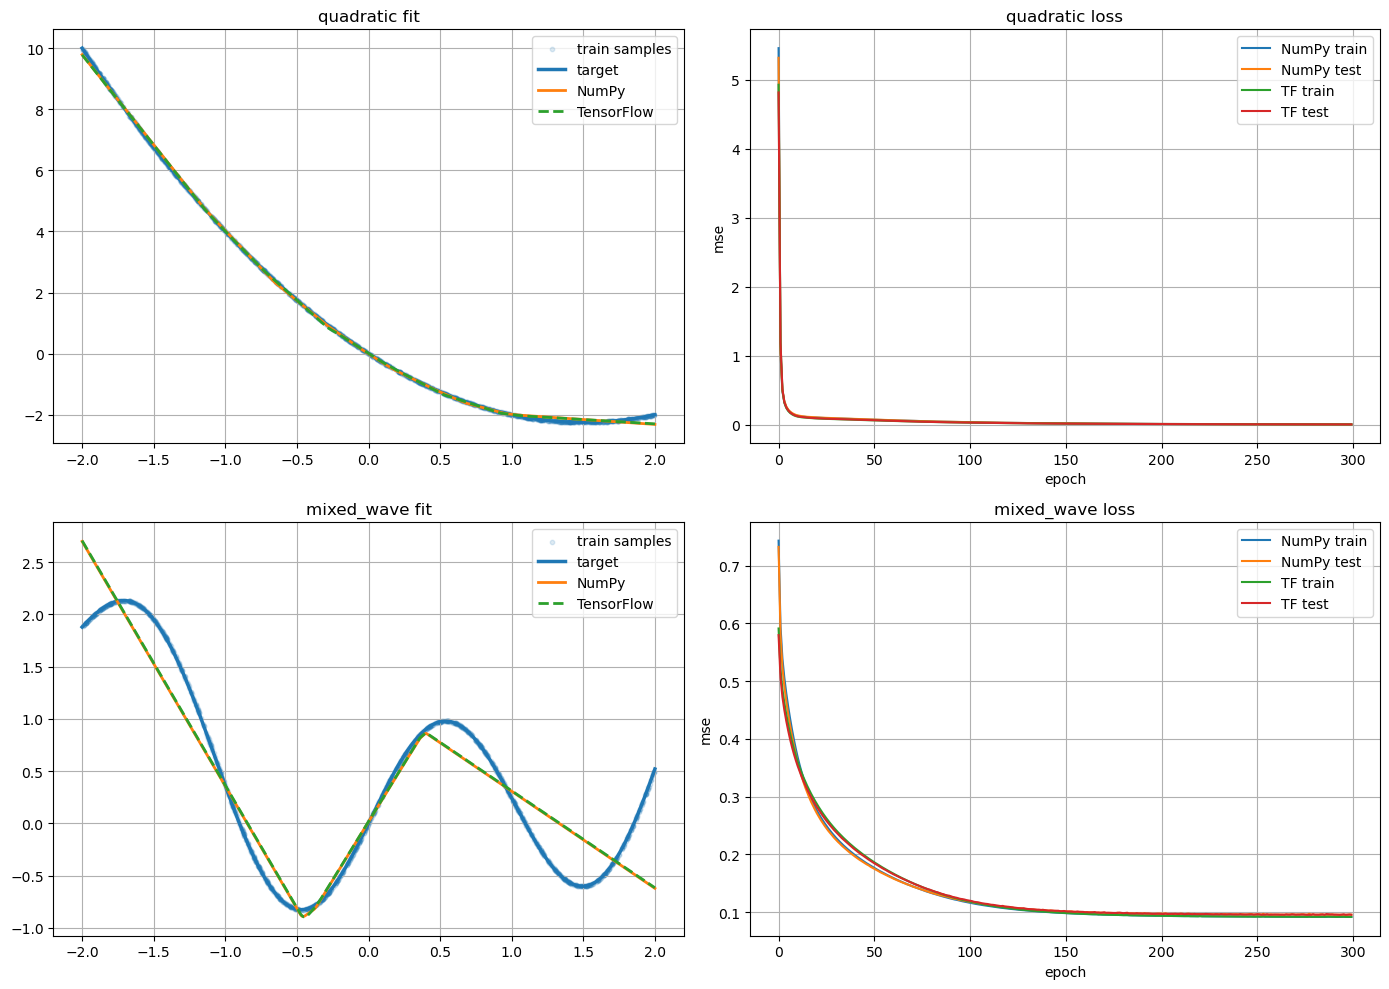

In [21]:
fig, axes = plt.subplots(len(results), 2, figsize=(14, 5 * len(results)))
if len(results) == 1:
    axes = np.array([axes])

for row, item in enumerate(results):
    x_train, y_train, x_test, y_test = item['data']
    order = np.argsort(x_test[:, 0])
    x_plot = x_test[order, 0]
    y_true = y_test[order, 0]
    y_numpy = item['numpy']['test_pred'][order, 0]
    y_tf = item['tensorflow']['test_pred'][order, 0]

    fit_ax = axes[row, 0]
    fit_ax.scatter(x_train[:, 0], y_train[:, 0], s=10, alpha=0.15, label='train samples')
    fit_ax.plot(x_plot, y_true, linewidth=2.5, label='target')
    fit_ax.plot(x_plot, y_numpy, linewidth=2.0, label='NumPy')
    fit_ax.plot(x_plot, y_tf, linewidth=2.0, linestyle='--', label='TensorFlow')
    fit_ax.set_title(f"{item['name']} fit")
    fit_ax.legend()

    loss_ax = axes[row, 1]
    loss_ax.plot(item['numpy']['history']['train_loss'], label='NumPy train')
    loss_ax.plot(item['numpy']['history']['test_loss'], label='NumPy test')
    loss_ax.plot(item['tensorflow']['history']['train_loss'], label='TF train')
    loss_ax.plot(item['tensorflow']['history']['test_loss'], label='TF test')
    loss_ax.set_title(f"{item['name']} loss")
    loss_ax.set_xlabel('epoch')
    loss_ax.set_ylabel('mse')
    loss_ax.legend()

plt.tight_layout()
plt.show()
